<a href="https://colab.research.google.com/github/u11410010-dotcom/-/blob/main/hw2_geophysics_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import importlib.util
import subprocess
import sys

# 在子程序檢查，避免安裝前先載入目前 kernel 的動態函式庫
check_code = """
import pygmt, pandas
import shutil
from pygmt.clib import Session
assert pygmt.__version__.lstrip('v').startswith('0.17.')
assert shutil.which('gs')
with Session() as session:
    assert session.info['version'].startswith('6.5.')
"""
try:
    ENV_READY = subprocess.run(
        [sys.executable, "-c", check_code], capture_output=True, timeout=30
    ).returncode == 0
except subprocess.TimeoutExpired:
    ENV_READY = False

IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False
if ENV_READY:
    print("環境已可用，跳過安裝。")
elif IN_COLAB:
    print("步驟 1/2：安裝 Conda（約 1 分鐘）。完成後 Colab 會自動重啟執行環境，等重新連線再執行下一格。", flush=True)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "condacolab==0.1.13"])
    import condacolab
    condacolab.install()
else:
    print("本機模式：使用目前 Python 環境。")


步驟 1/2：安裝 Conda（約 1 分鐘）。完成後 Colab 會自動重啟執行環境，等重新連線再執行下一格。

📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:12
🔁 Restarting kernel...


In [13]:
"""區域範本：一段板塊交界帶的地圖（地形 + 地震三段深度 + A–B 線與走廊 + 位置示意）
與 A–B 剖面（上方地形、下方距離–深度）。改最上面的參數就能換區域。

輸出：region_map.png、region_section.png
資料：USGS 地震目錄 API、GMT 全球地形 2 角分。
需要：pygmt 0.17（含 pandas、numpy）。需連網。
"""
import urllib.request

import numpy as np
import pandas as pd
import pygmt

# ==== 參數設定：日本琉球—台灣板塊交界帶 ====
# 範圍涵蓋：台灣東北部、琉球群島（宮古、八重山、沖繩）、琉球海溝、沖繩海槽
REGION = [120, 131, 21.5, 30.5]        # 西、東、南、北（經度、緯度）
START, MINMAG = "2000-01-01", 4.5       # 地震起始日與最低規模（M>=4.5 班尼奧夫帶清晰且未超出資料筆數上限）

# 剖面兩端：大致垂直琉球海溝走向（海溝走向 NE-SW，剖面採 NW-SE）
# A 在西北側（東海陸棚/沖繩海槽），B 在東南側（西菲律賓海盆）
# 選項 1（台灣東北—琉球西南段）：A = (122.0, 26.5), B = (125.0, 22.5)
# 選項 2（琉球中南段，標準島弧）：A = (124.5, 28.0), B = (128.5, 23.5)
A, B = (122.0, 26.5), (125.0, 22.5)     # 台灣東北至琉球海溝西端切線
HALF_WIDTH_KM = 100                     # 走廊半寬（km），走廊全寬 200 km
DEPTH_MAX = 700                         # 剖面深度軸下限；固定 700 km
OUT_MAP, OUT_SECTION = "region_map.png", "region_section.png"
# ======================================================

# 1. 地震：先查筆數，超過 20,000 自動提高規模門檻
base = "https://earthquake.usgs.gov/fdsnws/event/1/"
minmag = MINMAG
while True:
    query = (f"starttime={START}&minmagnitude={minmag}"
             f"&minlongitude={REGION[0]}&maxlongitude={REGION[1]}&minlatitude={REGION[2]}&maxlatitude={REGION[3]}")
    count = int(urllib.request.urlopen(base + "count?" + query).read())
    if count <= 20000:
        break
    minmag += 0.5
quakes = pd.read_csv(base + "query?format=csv&" + query).dropna(subset=["longitude", "latitude", "depth", "mag"])
print(f"USGS {START} 起 M >= {minmag}：{len(quakes)} 筆")

# 2. 走廊內地震投影到 A–B 線：distance 沿線距離、offset 離線距離（km）
selected = pygmt.project(data=quakes[["longitude", "latitude", "depth", "mag"]],
                         center=list(A), endpoint=list(B), unit=True, length="w",
                         width=[-HALF_WIDTH_KM, HALF_WIDTH_KM], convention="xypqz")
selected.columns = ["longitude", "latitude", "distance", "offset", "depth", "mag"]
selected = selected.sort_values("depth", ascending=False)
track = pygmt.project(center=list(A), endpoint=list(B), generate=5, unit=True)
track.columns = ["lon", "lat", "distance"]
length_km = float(track.distance.iloc[-1])
print(f"走廊內 {len(selected)} 筆；A–B 長 {length_km:.0f} km")

# 3. 地形：地圖用 02m；剖面沿 A–B 取樣
grid = pygmt.datasets.load_earth_relief(resolution="02m", region=REGION)
topo = pygmt.grdtrack(points=track[["lon", "lat"]], grid=grid, newcolname="z")


# 4. 走廊外框：沿線每點往左右各推 HALF_WIDTH_KM（球面近似，半徑 6371 km）
def bearing(lon1, lat1, lon2, lat2):
    """由 (lon1, lat1) 看向 (lon2, lat2) 的方位角（度，北為 0、順時針）"""
    p1, p2, dl = np.radians(lat1), np.radians(lat2), np.radians(np.subtract(lon2, lon1))
    x = np.sin(dl) * np.cos(p2)
    y = np.cos(p1) * np.sin(p2) - np.sin(p1) * np.cos(p2) * np.cos(dl)
    return np.degrees(np.arctan2(x, y))


def move(lon, lat, azimuth_deg, distance_km):
    """從 (lon, lat) 朝 azimuth 走 distance_km 後的位置"""
    p1, l1, az, d = np.radians(lat), np.radians(lon), np.radians(azimuth_deg), distance_km / 6371.0
    p2 = np.arcsin(np.sin(p1) * np.cos(d) + np.cos(p1) * np.sin(d) * np.cos(az))
    l2 = l1 + np.arctan2(np.sin(az) * np.sin(d) * np.cos(p1), np.cos(d) - np.sin(p1) * np.sin(p2))
    return np.degrees(l2), np.degrees(p2)


lon, lat = track.lon.to_numpy(), track.lat.to_numpy()
local_azimuth = bearing(lon[:-1], lat[:-1], lon[1:], lat[1:])
local_azimuth = np.append(local_azimuth, local_azimuth[-1])  # 最後一點沿用前一段方向
left_lon, left_lat = move(lon, lat, local_azimuth - 90, HALF_WIDTH_KM)
right_lon, right_lat = move(lon, lat, local_azimuth + 90, HALF_WIDTH_KM)
corridor_lon = np.concatenate([left_lon, right_lon[::-1]])
corridor_lat = np.concatenate([left_lat, right_lat[::-1]])


def mag_size(m):
    return min(0.05 * 2 ** (m - 5), 0.4)  # 有上限，避免 M9 把整張圖蓋掉


# 5. 地圖
fig = pygmt.Figure()
fig.grdimage(grid=grid, region=REGION, projection="M12c", cmap="geo", shading="+a-45+nt0.5",
             frame=["af", f"+tUSGS M>={minmag} since {START[:4]}"])
fig.coast(shorelines="0.3p,gray20", resolution="i")
pygmt.makecpt(cmap="#d7191c,#fdae61,#2c7bb6", series="0,70,300,700")  # 淺、中、深
fig.plot(x=quakes.longitude, y=quakes.latitude, size=quakes.mag.apply(mag_size) * 0.7,
         fill=quakes.depth, cmap=True, style="c", pen="0.1p,black", transparency=40)
fig.plot(x=corridor_lon, y=corridor_lat, close=True, pen="0.8p,black,--")
fig.plot(x=[A[0], B[0]], y=[A[1], B[1]], pen="1.5p,black")
fig.text(x=[A[0], B[0]], y=[A[1], B[1]], text=["A", "B"], font="10p,Helvetica-Bold",
         fill="white", pen="0.5p,black", offset="0c/0.3c")
fig.basemap(map_scale=f"jBL+c{(REGION[2] + REGION[3]) / 2}+w500k+o0.3c/0.3c+f+lkm")
fig.colorbar(position="JBC+w8c/0.3c+h+o0c/0.8c", frame=["a0", "+lDepth (km): 0-70 / 70-300 / 300-700"])
with fig.inset(position="jTR+w2.5c+o0.1c"):
    fig.coast(region="g", projection=f"G{(REGION[0] + REGION[1]) / 2}/{(REGION[2] + REGION[3]) / 2}/2.5c",
              land="gray70", water="white", frame="g")
    fig.plot(x=[REGION[0], REGION[1], REGION[1], REGION[0]], y=[REGION[2], REGION[2], REGION[3], REGION[3]],
             close=True, pen="1p,red")
fig.savefig(OUT_MAP, dpi=150)

# 6. 剖面：上方地形（各自尺度），下方距離–深度
fig = pygmt.Figure()
fig.basemap(region=[0, length_km, -11, 9], projection="X14c/2c", frame=["Wsne", "ya5f1+lTopo (km)"])
fig.plot(x=track.distance, y=topo.z / 1000, pen="0.8p,black")
fig.plot(x=[0, length_km], y=[0, 0], pen="0.3p,gray50,--")
fig.text(text="A", position="TL", offset="0.15c/-0.1c", font="10p,Helvetica-Bold")
fig.text(text="B", position="TR", offset="-0.15c/-0.1c", font="10p,Helvetica-Bold")
fig.shift_origin(yshift="-8.3c")
fig.basemap(region=[0, length_km, 0, DEPTH_MAX], projection="X14c/-8c",
            frame=["WSne", "xa200f100+lDistance from A (km)", "ya100f50+lDepth (km)"])
pygmt.makecpt(cmap="#d7191c,#fdae61,#2c7bb6", series="0,70,300,700")  # 新的 Figure 要重建色票
fig.plot(x=selected.distance, y=selected.depth, size=selected.mag.apply(mag_size),
         fill=selected.depth, cmap=True, style="c", pen="0.3p,black", transparency=20)
ve = (8 / DEPTH_MAX) / (14 / length_km)
fig.text(text=f"corridor +/-{HALF_WIDTH_KM} km, {len(selected)} events, VE = {ve:.1f}x (topo panel separate)",
         position="BL", offset="0.15c/0.15c", font="8p", fill="white@30")
fig.savefig(OUT_SECTION, dpi=150)

fixed = selected.depth.round(1).isin([10.0, 33.0, 35.0]).mean()
print(f"圖說骨架：USGS {START} 起 M >= {minmag}，範圍 {REGION}，A={A}、B={B}，走廊全寬 {2 * HALF_WIDTH_KM} km；"
      f"剖面 VE = {ve:.1f}x；走廊內 {fixed:.0%} 的深度是 USGS 預設值（10／33 km）。")
print("saved", OUT_MAP, OUT_SECTION)

USGS 2000-01-01 起 M >= 4.5：3797 筆
走廊內 560 筆；A–B 長 538 km
圖說骨架：USGS 2000-01-01 起 M >= 4.5，範圍 [120, 131, 21.5, 30.5]，A=(122.0, 26.5)、B=(125.0, 22.5)，走廊全寬 200 km；剖面 VE = 0.4x；走廊內 41% 的深度是 USGS 預設值（10／33 km）。
saved region_map.png region_section.png


In [2]:
"""火山與熱點：全球圖，加上日本（火山弧對地震深度）與夏威夷（熱點，不是交界）兩個局部圖。

輸出：volcanoes_hotspots.png
資料：NOAA NCEI 火山位置 API（全新世清單，源自 Smithsonian GVP）、GMT 範例檔 @hotspots.txt、
      USGS 地震目錄 API、GMT 全球地形。
需要：pygmt 0.17（含 pandas）。需連網。
"""
import json
import urllib.request

import pandas as pd
import pygmt

OUT = "volcanoes_hotspots.png"

# 1. 火山：NCEI，每頁 200 筆
rows, page = [], 1
while True:
    url = f"https://www.ngdc.noaa.gov/hazel/hazard-service/api/v1/volcanolocs?itemsPerPage=200&page={page}"
    with urllib.request.urlopen(url) as response:
        data = json.load(response)
    rows += data["items"]
    if page >= data["totalPages"]:
        break
    page += 1
volc = pd.DataFrame(rows).dropna(subset=["latitude", "longitude"])

# 2. 熱點：GMT 範例檔
hot = pd.read_csv(pygmt.which("@hotspots.txt", download="c"), sep=r"\s+", comment="#", header=None,
                  usecols=[0, 1], names=["lon", "lat"])
print("volcanoes:", len(volc), "hotspots:", len(hot))

DEPTH_EDGES, DEPTH_COLORS = "0,70,300,700", "#d7191c,#fdae61,#2c7bb6"


def quakes(region, start, minmag):
    q = (f"format=csv&starttime={start}&minmagnitude={minmag}&minlongitude={region[0]}"
         f"&maxlongitude={region[1]}&minlatitude={region[2]}&maxlatitude={region[3]}")
    return pd.read_csv("https://earthquake.usgs.gov/fdsnws/event/1/query?" + q).dropna(
        subset=["longitude", "latitude", "depth", "mag"])


fig = pygmt.Figure()
pygmt.config(FONT_ANNOT_PRIMARY="8p", FONT_LABEL="9p", FONT_TITLE="11p", MAP_FRAME_TYPE="plain")

# (a) 全球：地形 + 火山 + 熱點
fig.grdimage(grid="@earth_relief_10m", region="d", projection="N150/22c", cmap="geo", shading="+a-45+nt0.4",
             frame=["+tHolocene volcanoes (NCEI/GVP) and hotspots (Mueller et al. 1993)", "g30"])
fig.coast(shorelines="0.15p,gray30")
fig.plot(x=volc.longitude, y=volc.latitude, style="t0.12c", fill="red", pen="0.1p,black")
fig.plot(x=hot.lon, y=hot.lat, style="a0.35c", fill="yellow", pen="0.4p,black")
fig.plot(x=[-175], y=[-75], style="t0.25c", fill="red", pen="0.1p,black")
fig.text(x=-170, y=-75, text="Holocene volcano", justify="ML", font="8p")
fig.plot(x=[-175], y=[-82], style="a0.4c", fill="yellow", pen="0.4p,black")
fig.text(x=-170, y=-82, text="Hotspot", justify="ML", font="8p")

# (b) 日本：火山弧落在橘色中源震正上方
fig.shift_origin(yshift="-9.5c")
reg = [128, 150, 30, 46]
q = quakes(reg, "2010-01-01", 4.5).sort_values("depth", ascending=False)
fig.grdimage(grid=pygmt.datasets.load_earth_relief("02m", region=reg), region=reg, projection="M9c",
             cmap="geo", shading="+a-45+nt0.5", frame=["WSne+tJapan: volcanic arc vs earthquake depth", "a5f1"])
fig.coast(shorelines="0.3p,gray20", resolution="i")
pygmt.makecpt(cmap=DEPTH_COLORS, series=DEPTH_EDGES)
fig.plot(x=q.longitude, y=q.latitude, style="c0.06c", fill=q.depth, cmap=True, transparency=50)
v = volc[(volc.longitude.between(*reg[:2])) & (volc.latitude.between(*reg[2:]))]
fig.plot(x=v.longitude, y=v.latitude, style="t0.22c", fill="white", pen="0.6p,black")
fig.basemap(map_scale="jBL+c38+w500k+o0.3c/0.3c+f+lkm")
fig.text(text=f"{len(v)} volcanoes; quakes USGS M>=4.5 since 2010, red<70 / orange 70-300 / blue>300 km",
         position="TL", offset="0.15c/-0.15c", font="6p", fill="white@30")

# (c) 夏威夷：熱點鏈，只有淺震、只在年輕端
fig.shift_origin(xshift="11c")
reg = [-162, -152, 17, 24]
q = quakes(reg, "2010-01-01", 4.0).sort_values("depth", ascending=False)
fig.grdimage(grid=pygmt.datasets.load_earth_relief("01m", region=reg), region=reg, projection="M9c",
             cmap="geo", shading="+a-45+nt0.5", frame=["WSne+tHawaii: hotspot, no boundary", "a2f1"])
fig.coast(shorelines="0.3p,gray20", resolution="h")
pygmt.makecpt(cmap=DEPTH_COLORS, series=DEPTH_EDGES)
fig.plot(x=q.longitude, y=q.latitude, style="c0.08c", fill=q.depth, cmap=True, transparency=40)
v = volc[(volc.longitude.between(*reg[:2])) & (volc.latitude.between(*reg[2:]))]
fig.plot(x=v.longitude, y=v.latitude, style="t0.25c", fill="white", pen="0.6p,black")
h = hot[(hot.lon.between(*reg[:2])) & (hot.lat.between(*reg[2:]))]
fig.plot(x=h.lon, y=h.lat, style="a0.6c", fill="yellow", pen="0.6p,black")
fig.basemap(map_scale="jBL+c20+w200k+o0.3c/0.3c+f+lkm")
fig.text(text=f"{len(v)} volcanoes, {len(h)} hotspot; quakes USGS M>=4 since 2010, all shallow, only at the young end",
         position="TL", offset="0.15c/-0.15c", font="6p", fill="white@30")

fig.savefig(OUT, dpi=150)
print("saved", OUT)

grdimage [NOTICE]: Remote data courtesy of GMT data server oceania [http://oceania.generic-mapping-tools.org]
grdimage [NOTICE]: SRTM15 Earth Relief v2.7 at 10x10 arc minutes reduced by Gaussian Cartesian filtering (52.4 km fullwidth) [Tozer et al., 2019].
grdimage [NOTICE]:   -> Download grid file [3.0M]: earth_relief_10m_p.grd


volcanoes: 1609 hotspots: 55


grdblend [NOTICE]: Remote data courtesy of GMT data server oceania [http://oceania.generic-mapping-tools.org]
grdblend [NOTICE]: SRTM15 Earth Relief v2.7 at 01x01 arc minutes reduced by Gaussian Cartesian filtering (5.2 km fullwidth) [Tozer et al., 2019].
grdblend [NOTICE]:   -> Download 30x30 degree grid tile (earth_relief_01m_g): N00W180


saved volcanoes_hotspots.png


展示圖片: region_map.png


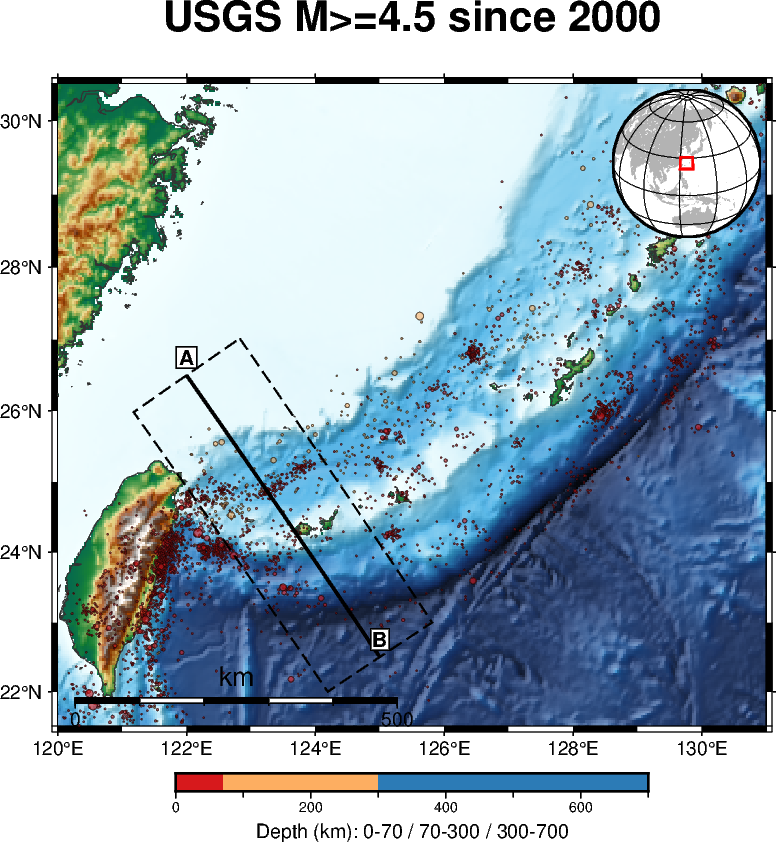

展示圖片: region_section.png


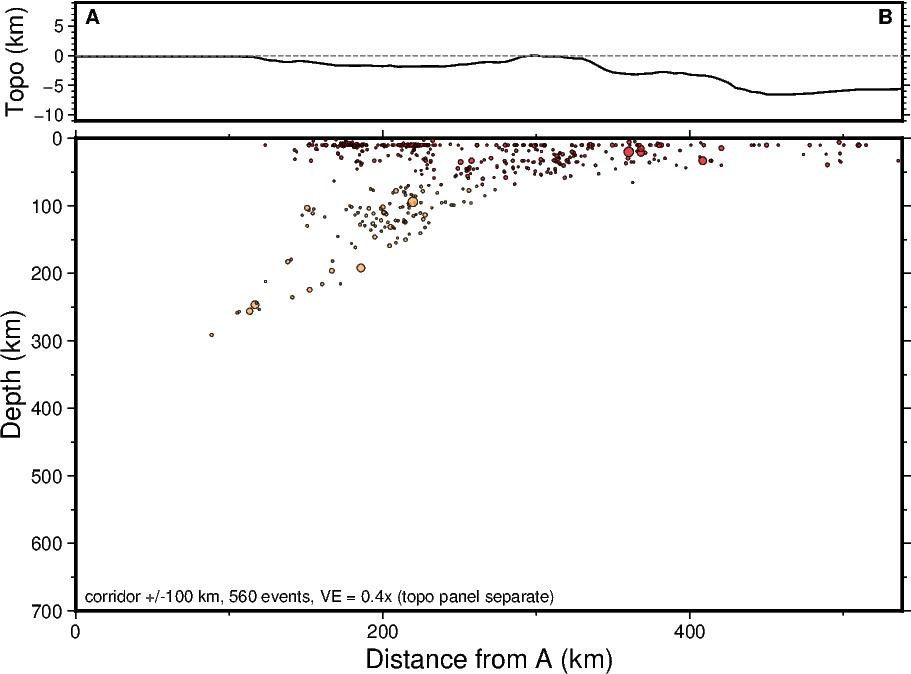

展示圖片: volcanoes_hotspots.png


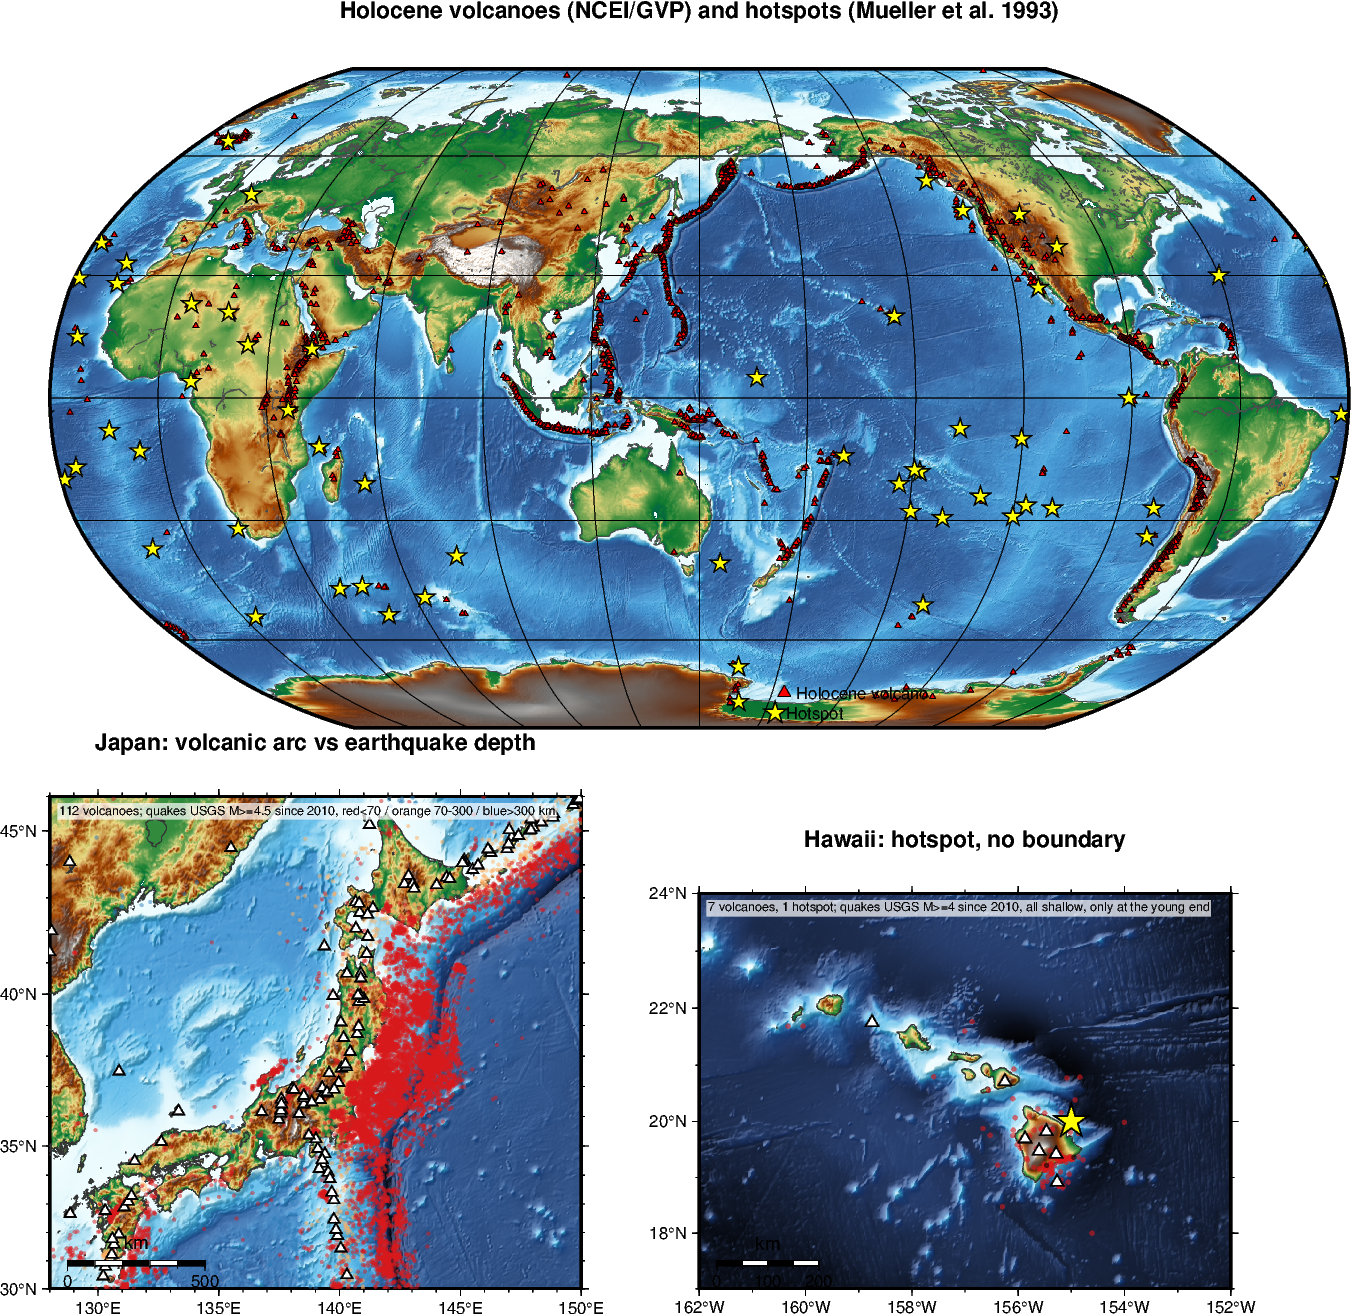

In [14]:
from IPython.display import Image, display
import os

# 檢查並顯示產生的圖片檔
image_files = ["region_map.png", "region_section.png", "volcanoes_hotspots.png"]

for img_file in image_files:
    if os.path.exists(img_file):
        print(f"展示圖片: {img_file}")
        display(Image(filename=img_file))
    else:
        print(f"未找到圖片檔案: {img_file}")


已成功產生含資料註記的圖表！


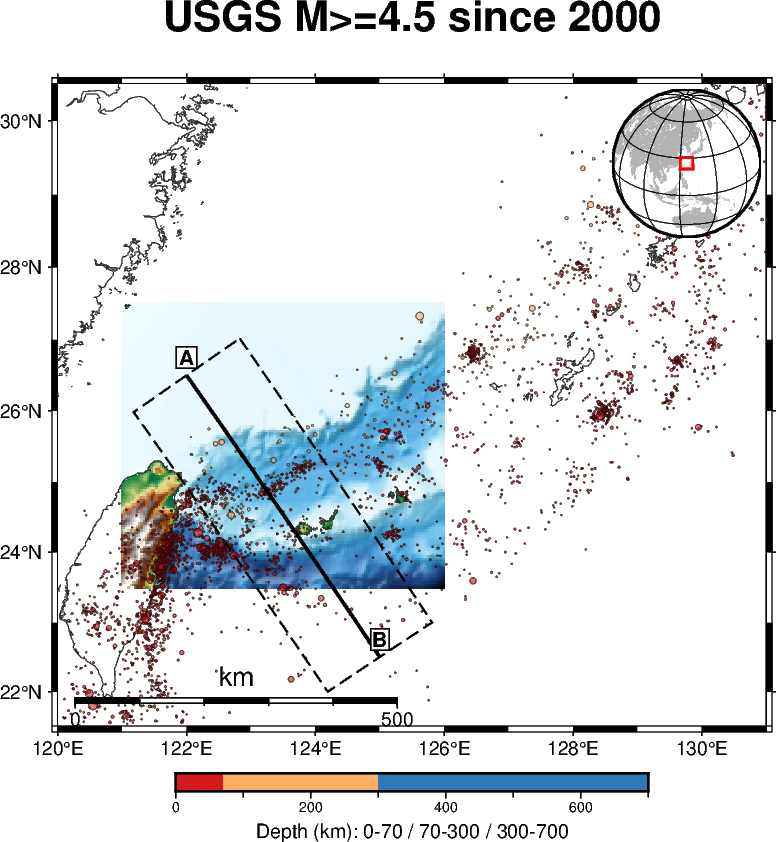

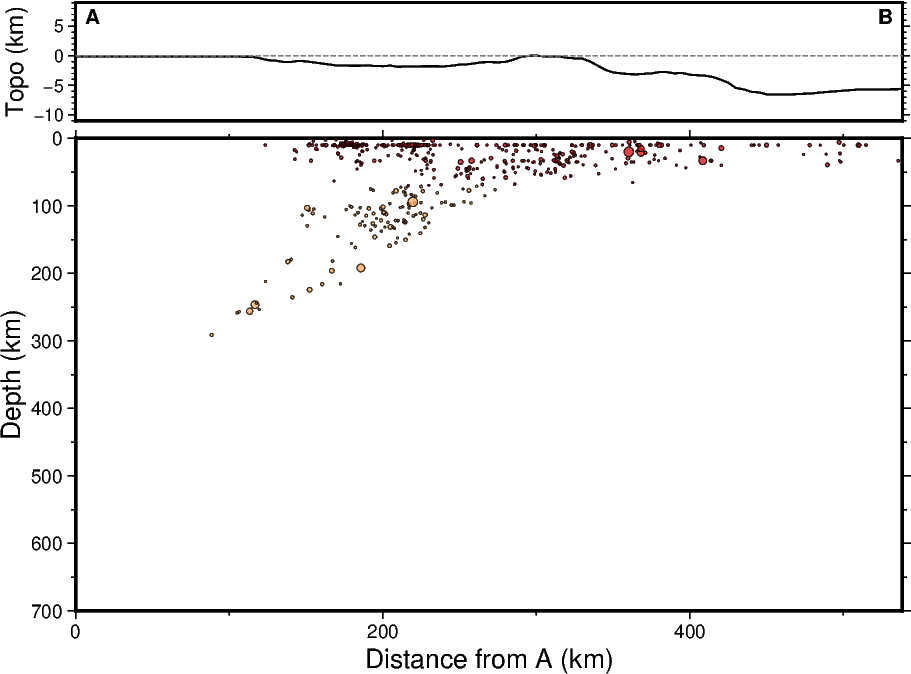

In [20]:
# 重新繪製並加入使用者指定的詳細資料註記 (Metadata Annotations)
import pygmt
import pandas as pd
import numpy as np
from IPython.display import Image, display

# 計算 USGS 預設深度的比例
fixed_percentage = selected["depth"].round(1).isin([10.0, 33.0, 35.0]).mean() * 100

# 註記文字內容
annotation_text = (
    f"Source: USGS FDSN API\n"
    f"Time: {START} to Present\n"
    f"Threshold: M >= {minmag}\n"
    f"Corridor half-width: {HALF_WIDTH_KM} km\n"
    f"USGS default depths (10/33km): {fixed_percentage:.1f}%"
)

# ==================== 1. 重新繪製地圖 (region_map.png) ====================
fig_map = pygmt.Figure()
fig_map.grdimage(grid=grid, region=REGION, projection="M12c", cmap="geo", shading="+a-45+nt0.5",
                 frame=["af", f"+tUSGS M>={minmag} since {START[:4]}"])
fig_map.coast(shorelines="0.3p,gray20", resolution="i")

pygmt.makecpt(cmap="#d7191c,#fdae61,#2c7bb6", series="0,70,300,700")
fig_map.plot(x=quakes.longitude, y=quakes.latitude, size=quakes.mag.apply(mag_size) * 0.7,
             fill=quakes.depth, cmap=True, style="c", pen="0.1p,black", transparency=40)
fig_map.plot(x=corridor_lon, y=corridor_lat, close=True, pen="0.8p,black,--")
fig_map.plot(x=[A[0], B[0]], y=[A[1], B[1]], pen="1.5p,black")
fig_map.text(x=[A[0], B[0]], y=[A[1], B[1]], text=["A", "B"], font="10p,Helvetica-Bold",
             fill="white", pen="0.5p,black", offset="0c/0.3c")

# 繪製比例尺與色標
fig_map.basemap(map_scale=f"jBL+c{(REGION[2] + REGION[3]) / 2}+w500k+o0.3c/0.3c+f+lkm")
fig_map.colorbar(position="JBC+w8c/0.3c+h+o0c/0.8c", frame=["a0", "+lDepth (km): 0-70 / 70-300 / 300-700"])

# 疊加詳細資料來源與註記框於地圖左上角
fig_map.text(
    position="jTL",
    text=annotation_text,
    font="7p,Helvetica,black",
    fill="white@20",
    pen="0.5p,gray40",
    offset="0.2c/-0.2c",
    justify="TL"
)

# 右上角插圖
with fig_map.inset(position="jTR+w2.5c+o0.1c"):
    fig_map.coast(region="g", projection=f"G{(REGION[0] + REGION[1]) / 2}/{(REGION[2] + REGION[3]) / 2}/2.5c",
                  land="gray70", water="white", frame="g")
    fig_map.plot(x=[REGION[0], REGION[1], REGION[1], REGION[0]], y=[REGION[2], REGION[2], REGION[3], REGION[3]],
                 close=True, pen="1p,red")

fig_map.savefig(OUT_MAP, dpi=150)

# ==================== 2. 重新繪製剖面圖 (region_section.png) ====================
fig_sec = pygmt.Figure()
fig_sec.basemap(region=[0, length_km, -11, 9], projection="X14c/2c", frame=["Wsne", "ya5f1+lTopo (km)"])
fig_sec.plot(x=track.distance, y=topo.z / 1000, pen="0.8p,black")
fig_sec.plot(x=[0, length_km], y=[0, 0], pen="0.3p,gray50,--")
fig_sec.text(text="A", position="TL", offset="0.15c/-0.1c", font="10p,Helvetica-Bold")
fig_sec.text(text="B", position="TR", offset="-0.15c/-0.1c", font="10p,Helvetica-Bold")

fig_sec.shift_origin(yshift="-8.3c")
fig_sec.basemap(region=[0, length_km, 0, DEPTH_MAX], projection="X14c/-8c",
            frame=["WSne", "xa200f100+lDistance from A (km)", "ya100f50+lDepth (km)"])
pygmt.makecpt(cmap="#d7191c,#fdae61,#2c7bb6", series="0,70,300,700")
fig_sec.plot(x=selected.distance, y=selected.depth, size=selected.mag.apply(mag_size),
         fill=selected.depth, cmap=True, style="c", pen="0.3p,black", transparency=20)

# 剖面圖左下角加上註記框
fig_sec.text(
    position="jBL",
    text=annotation_text,
    font="7p,Helvetica,black",
    fill="white@20",
    pen="0.5p,gray40",
    offset="0.2c/0.2c",
    justify="BL"
)

fig_sec.savefig(OUT_SECTION, dpi=150)

# 展示結果
print("已成功產生含資料註記的圖表！")
display(Image(filename=OUT_MAP))
display(Image(filename=OUT_SECTION))
